In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler

In [12]:
df = pd.read_csv("data/car_evaluation.tsv", sep='\t')
df

,buying_price,maintenance_costs,doors,seats,luggage_boot,safety,target
0,3,3,0,0,0,0,0
1,3,3,0,0,0,1,0
2,3,3,0,0,0,2,0
3,3,3,0,0,1,0,0
4,3,3,0,0,1,1,0
...,...,...,...,...,...,...,...
1723,0,0,3,2,1,1,2
1724,0,0,3,2,1,2,3
1725,0,0,3,2,2,0,0
1726,0,0,3,2,2,1,2


In [13]:
x_col = len(df.columns[:-1])

In [14]:
X = df.iloc[:, 0:x_col].values
print(X)

[[3 3 0 0 0 0]
 [3 3 0 0 0 1]
 [3 3 0 0 0 2]
 ...
 [0 0 3 2 2 0]
 [0 0 3 2 2 1]
 [0 0 3 2 2 2]]


In [15]:
y = df.iloc[:, -1].values
print(y)

[0 0 0 ... 0 2 3]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1382, 6)
(346, 6)
(1382,)
(346,)


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## SVM

In [18]:
model = SVC(kernel='rbf', degree=4, gamma='scale', C=1)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [19]:
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))

report = classification_report(y_test, y_pred)
print(report)

Accuracy: 0.9624277456647399
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       247
           1       0.88      0.96      0.92        79
           2       1.00      1.00      1.00        10
           3       1.00      0.90      0.95        10

    accuracy                           0.96       346
   macro avg       0.97      0.96      0.96       346
weighted avg       0.96      0.96      0.96       346



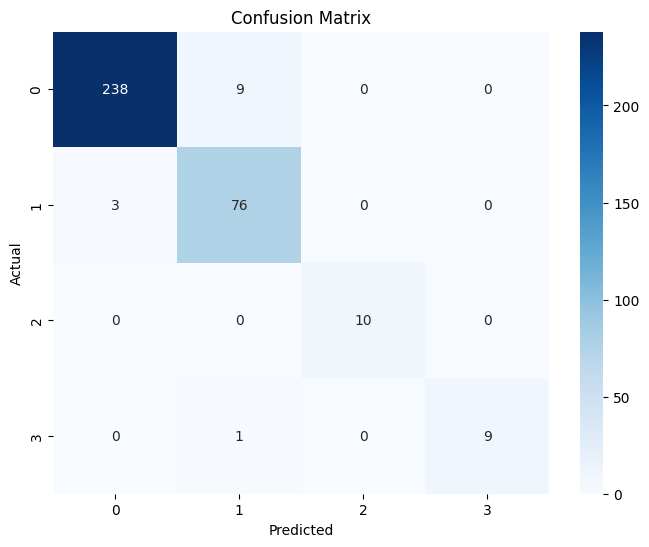

In [20]:
plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Figure/svc_confusion_matrix.pdf')
plt.show()

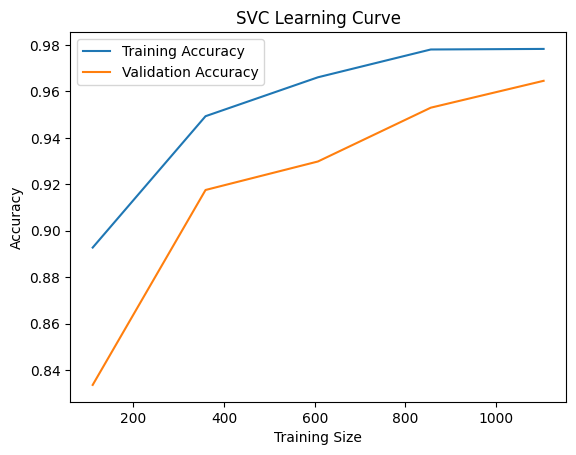

In [21]:
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training Accuracy')
plt.plot(train_sizes, test_mean, label='Validation Accuracy')

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("SVC Learning Curve")

plt.legend()
plt.savefig('Figure/svc_learning_curve.pdf')
plt.show()

## Naive Bayes

In [22]:
model_NB = MultinomialNB()
model_NB.fit(X_train, y_train)
y_pred2 = model_NB.predict(X_test)

In [23]:
cm2 = confusion_matrix(y_test, y_pred2)
print("Accuracy:", accuracy_score(y_test, y_pred2))
report2 = classification_report(y_test, y_pred2)
print(report2)

Accuracy: 0.7283236994219653
              precision    recall  f1-score   support

           0       0.75      0.99      0.86       247
           1       0.35      0.08      0.12        79
           2       0.25      0.10      0.14        10
           3       0.00      0.00      0.00        10

    accuracy                           0.73       346
   macro avg       0.34      0.29      0.28       346
weighted avg       0.63      0.73      0.64       346



c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

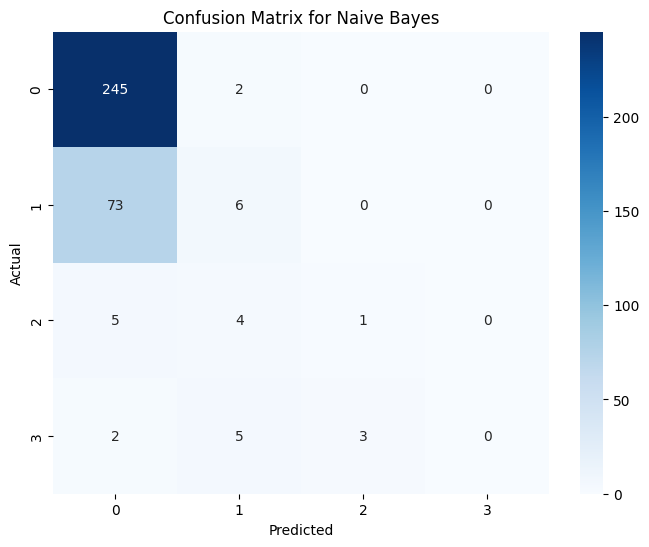

In [24]:
plt.figure(figsize=(8, 6))
plt.title('Confusion Matrix for Naive Bayes')
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Figure/nb_confusion_matrix.pdf')
plt.show()

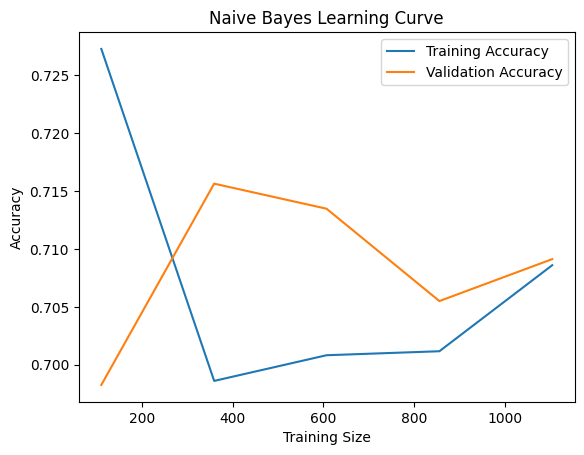

In [25]:
train_sizes, train_scores, test_scores = learning_curve(
    model_NB,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training Accuracy')
plt.plot(train_sizes, test_mean, label='Validation Accuracy')

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Naive Bayes Learning Curve")

plt.legend()
plt.savefig('Figure/nb_learning_curve.pdf')
plt.show()